The notebook compares the square root filter with the normal kalman filter using linear measurement and dynamic models.

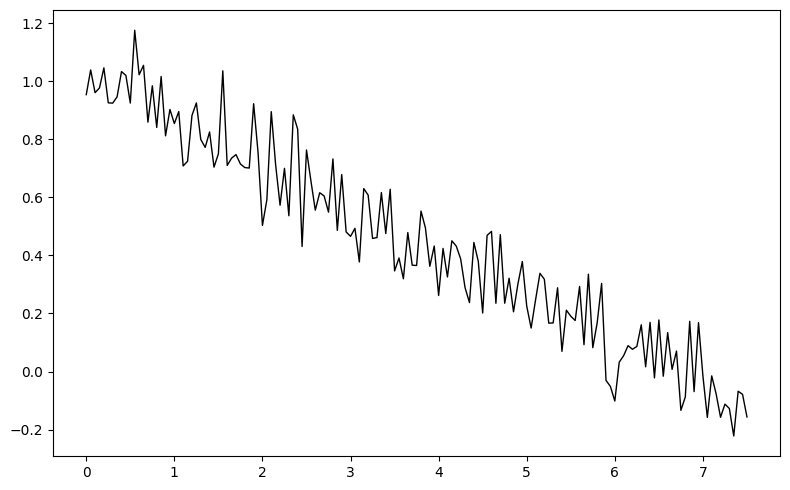

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from numpy.random import default_rng
from numpy.typing import NDArray

from pyfilter.models.linear import GaussianSelectionTransform, IntegratorChainTransition


def generate_data(
    x0: NDArray[np.floating],
    n: int,
    dt: float,
) -> NDArray[np.floating]:
    generating_transition = IntegratorChainTransition(n=3, p=3, dtype=x0.dtype)
    x = np.zeros((n + 1, 9), dtype=x0.dtype)
    x[0] = x0.copy()
    dt_ = np.array(dt)
    for i in range(1, n + 1):
        x[i] = generating_transition.transform(x[i - 1], dt_)

    return x


x0 = np.array([1, -10, 1, -0.15, 0.03, 1, 0.001, 0.01, -0.2], dtype=np.float32)

dt = 0.05
n = 150
sigma = 0.1
x = generate_data(x0, n, dt)
rng = default_rng(seed=45)
noise = rng.normal(scale=sigma, size=(n + 1, 9)).astype(x0.dtype)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(np.arange(0, dt * (n + 1), dt), x[:, 0] + noise[:, 0], lw=1.0, color="k")
fig.tight_layout()

## Construct Filters

In [ ]:
from pyfilter.filter.linear import LinearGaussianKalman, SquareRootLinearGuassianKalman
from pyfilter.types import GaussianRV
from pyfilter.types.covariance import (
    CholeskyFactorCovariance,
    DiagonalCovariance,
)
from pyfilter.types.process_noise import WeinerProcessNoise

base_filter = LinearGaussianKalman(
    IntegratorChainTransition(n=3, p=3, dtype=x0.dtype),
    WeinerProcessNoise(3, 3, np.array(sigma, dtype=x0.dtype), dtype=x0.dtype),
    GaussianSelectionTransform(slice(0, 3), 9, dtype=x0.dtype),
)
square_root_filter = SquareRootLinearGuassianKalman(
    IntegratorChainTransition(n=3, p=3, dtype=x0.dtype),
    WeinerProcessNoise(3, 3, np.array(sigma, dtype=x0.dtype), dtype=x0.dtype),
    GaussianSelectionTransform(slice(0, 3), 9, dtype=x0.dtype),
)

z_scale = 1e3


init_std = np.ones((1, 9))
init_std[:3] *= 0.1
init_std[:, 2] *= z_scale
init_std[:, 3:] *= 10
x0_transform = x0.copy()
x0_transform[2] *= z_scale


xinit = GaussianRV(x0_transform[np.newaxis, :], DiagonalCovariance(init_std))

x_base_sample = rng.normal(size=(1, 9)).astype(xinit.mean.dtype)
x_base_mean = (
    np.einsum("...ij,...j->...i", xinit.covariance.cholesky_factor, x_base_sample)
    + xinit.mean
)
x_base = GaussianRV(
    x_base_mean.copy().astype(x0.dtype), xinit.covariance.full().astype(x0.dtype)
)
x_sqrt = GaussianRV(
    x_base_mean.copy().astype(x0.dtype),
    CholeskyFactorCovariance(xinit.covariance.cholesky_factor.astype(x0.dtype)),
)

x_transform = x.copy()
x_transform[:, 3] *= z_scale

measurement_mean = x_transform[:, :3] + noise[:, :3]

delta_t = np.array([dt], dtype=np.float32)
x_base_list: list[GaussianRV] = []
x_sqrt_list: list[GaussianRV] = []
for i in range(measurement_mean.shape[0]):
    measurement = GaussianRV(
        mean=measurement_mean[i : i + 1],
        covariance=DiagonalCovariance(np.ones((1, 3), dtype=np.float32) * 1e-1),
    )
    # x_base_pred = base_filter.predict(x_base,delta_t)
    # x_base = base_filter.update(x_base_pred,measurement)
    # x_base_list.append(x_base)

    x_sqrt_pred = square_root_filter.predict(x_sqrt, delta_t)
    x_sqrt = square_root_filter.update(x_sqrt_pred, measurement)
    x_sqrt_list.append(x_sqrt)


# x_base_filter = GaussianRV.concatenate(x_base_list)
x_sqrt_filter = GaussianRV.concatenate(x_sqrt_list)
print(x_sqrt_filter.mean.dtype)

float64


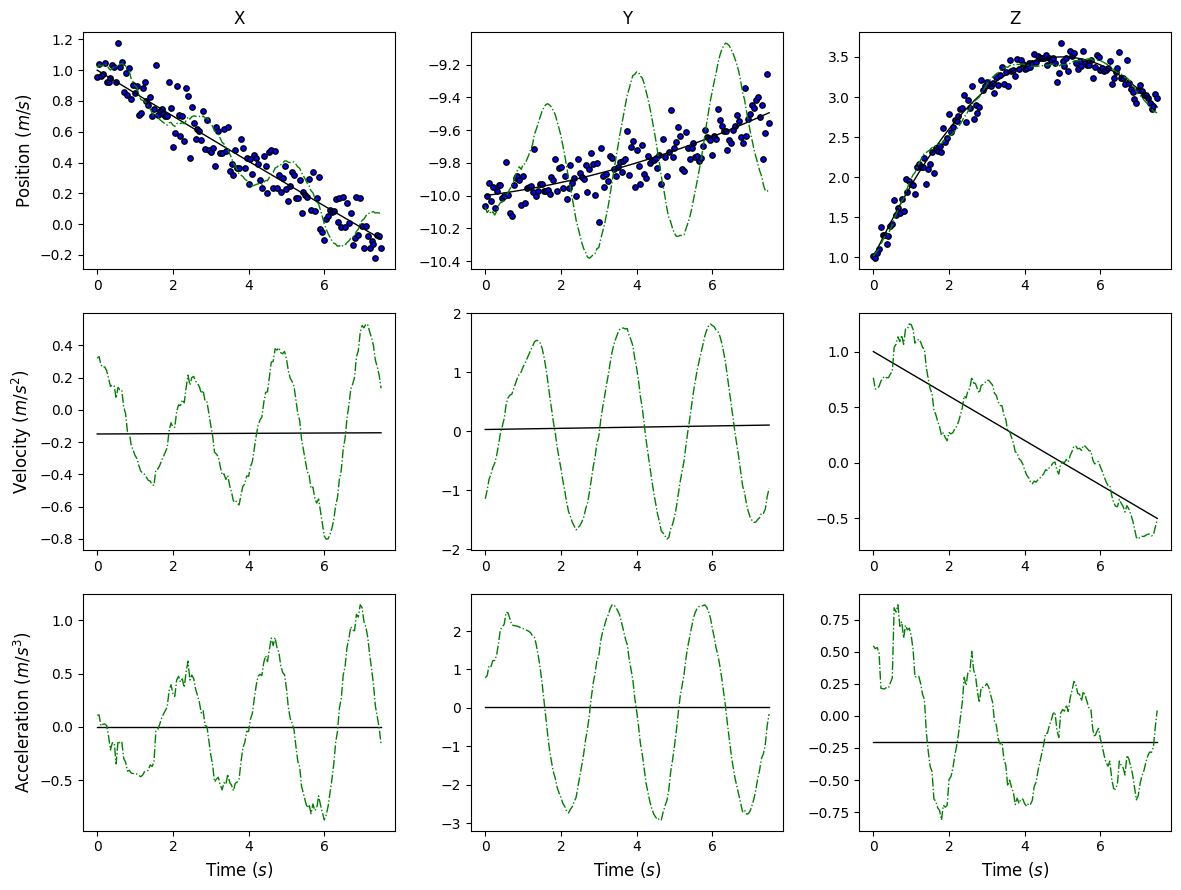

In [3]:
fig, axes = plt.subplots(figsize=(12, 9), nrows=3, ncols=3)


for i, ax in enumerate(axes.flat):
    time = np.arange(0, dt * (n + 1), dt)
    ax.plot(time, x[:, i], lw=1.0, color="k", ls="-", label="Truth")
    # ax.plot(time,x_base_filter.mean[:,i],lw = 1.0, color = "red",label = "Base Filter",ls = '--')
    ax.plot(
        time,
        x_sqrt_filter.mean[:, i],
        lw=1.0,
        color="green",
        label="Square Root Filter",
        ls="-.",
    )

    if i < 3:
        ax.scatter(
            time,
            x[:, i] + noise[:, i],
            s=15,
            facecolor="blue",
            edgecolor="k",
            label="Measurements",
        )

y_labels = [r"Position $(m/s)$", r"Velocity $(m/s^2)$", r"Acceleration $(m/s^3)$"]
titles = ["X", "Y", "Z"]

for ax, label in zip(axes[:, 0], y_labels, strict=False):
    ax.set_ylabel(label, fontsize=12)

for ax, label in zip(axes[0, :], titles, strict=False):
    ax.set_title(label, fontsize=12)

for ax in axes[-1, :]:
    ax.set_xlabel(r"Time $(s)$", fontsize=12)

fig.tight_layout()